# **1. 데이터 불러오기**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv(r"C:\Users\user\Desktop\DA5\trip\trip.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22701 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22701 non-null  object 
 1   tpep_pickup_datetime   22701 non-null  object 
 2   tpep_dropoff_datetime  22701 non-null  object 
 3   payment_method         22701 non-null  object 
 4   passenger_count        22701 non-null  int64  
 5   trip_distance          22701 non-null  float64
 6   fare_amount            22698 non-null  float64
 7   tip_amount             22701 non-null  float64
 8   tolls_amount           22701 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 1.6+ MB


# **2. 결측치 처리**

In [3]:
# 결측치 행 삭제
df = df.dropna(subset=['fare_amount'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22698 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22698 non-null  object 
 1   tpep_pickup_datetime   22698 non-null  object 
 2   tpep_dropoff_datetime  22698 non-null  object 
 3   payment_method         22698 non-null  object 
 4   passenger_count        22698 non-null  int64  
 5   trip_distance          22698 non-null  float64
 6   fare_amount            22698 non-null  float64
 7   tip_amount             22698 non-null  float64
 8   tolls_amount           22698 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 1.7+ MB


In [4]:
# 중복 삭제
df = df.drop_duplicates()

In [5]:
df.describe()

,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
count,22696.000000,22696.000000,22696.000000,22696.000000,22696.000000
mean,1.643638,2.912231,13.023681,1.835363,0.312329
std,1.305027,3.651483,13.240551,2.800182,1.398834
min,0.000000,0.000000,-120.000000,0.000000,0.000000
25%,1.000000,0.990000,6.500000,0.000000,0.000000
50%,1.000000,1.610000,9.500000,1.350000,0.000000
75%,2.000000,3.060000,14.500000,2.450000,0.000000
max,36.000000,33.960000,999.990000,200.000000,19.100000


# **3. 이상치 탐지**

### **1) 승객 수**

In [6]:
df['passenger_count'].sort_values(ascending=False)

64       36
21856     6
10703     6
0         6
3162      6
         ..
4062      0
3354      0
1927      0
1876      0
1518      0
Name: passenger_count, Length: 22696, dtype: int64

In [7]:
df.loc[df['passenger_count'] == 36]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
64,Manuel Dickson,10/05/2017 9:39:28 AM,10/05/2017 9:42:32 AM,Debit Card,36,0.22,21.5,0.0,0.0


In [8]:
# 이상치 삭제
df = df.drop(index=64)

### **2) 이동 거리**

In [20]:
df['trip_distance'].sort_values(ascending=False).head(20)

9282     33.96
13863    33.92
6066     32.72
10293    31.95
30       30.83
18132    30.50
5794     30.33
15352    28.23
10304    28.20
2594     27.97
20614    27.88
1910     27.34
20547    27.20
4140     26.86
15171    26.54
1498     26.39
7219     26.20
19485    26.12
910      26.12
4717     25.86
Name: trip_distance, dtype: float64

In [10]:
df[df['trip_distance'] == 0]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
129,Linda Kaufman,06/22/2017 8:05:33 AM,06/22/2017 8:05:40 AM,Debit Card,1,0.0,20.0,0.00,0.0
248,Erik Perez,09/18/2017 8:50:53 PM,09/18/2017 8:51:03 PM,Cash,1,0.0,2.5,0.00,0.0
293,Deborah Sanford,10/04/2017 7:46:24 PM,10/04/2017 7:46:50 PM,Cash,1,0.0,2.5,0.00,0.0
321,Ryan Hughes,02/22/2017 4:01:44 AM,02/22/2017 4:01:53 AM,Cash,1,0.0,2.5,0.00,0.0
426,David Parker,01/14/2017 7:00:26 AM,01/14/2017 7:00:53 AM,Cash,1,0.0,2.5,6.70,0.0
...,...,...,...,...,...,...,...,...,...
22192,Angela French,10/16/2017 8:34:07 AM,10/16/2017 8:34:10 AM,Credit Card,1,0.0,2.5,0.00,0.0
22327,Kelsey Rogers,07/21/2017 11:30:29 PM,07/21/2017 11:31:12 PM,Debit Card,1,0.0,16.8,3.42,0.0
22385,Joseph Castillo,01/07/2017 4:48:42 AM,01/07/2017 4:51:03 AM,Cash,1,0.0,10.0,0.00,0.0
22568,Christine Edwards,03/07/2017 2:24:47 AM,03/07/2017 2:24:50 AM,Credit Card,1,0.0,0.0,0.00,0.0


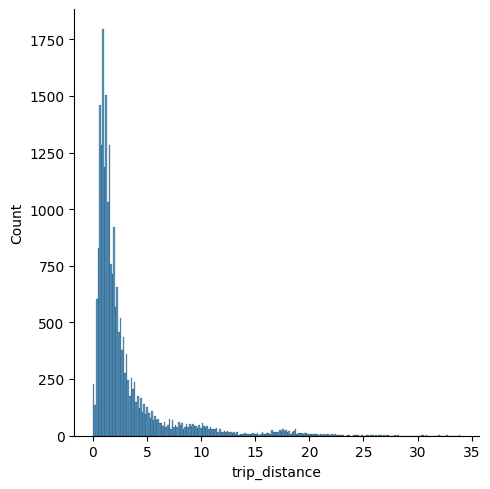

In [21]:
sns.displot(df['trip_distance'])

### **3) 택시 요금**

In [12]:
df['fare_amount'].sort_values(ascending=False).head(20)

8478     999.99
20314    450.00
13863    200.01
15476    200.00
12513    175.00
3584     152.00
9282     150.00
16381    140.00
10293    131.00
1930     120.00
11271    120.00
6066     107.00
13623    105.00
6710     100.00
7283     100.00
14997    100.00
910      100.00
11610     99.50
11841     99.00
6880      98.50
Name: fare_amount, dtype: float64

In [26]:
df.loc[[8478, 20314, 13863, 15476, 12513]]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
8478,Alexis Hanson,02/06/2017 5:50:10 AM,02/06/2017 5:51:08 AM,Credit Card,1,2.60,999.99,200.00,0.00
20314,Nicholas Thomas,12/19/2017 9:40:46 AM,12/19/2017 9:40:55 AM,Cash,2,0.00,450.00,0.00,0.00
13863,William Yates,05/19/2017 8:20:21 AM,05/19/2017 9:20:30 AM,Credit Card,1,33.92,200.01,51.64,5.76
15476,James Dyer MD,06/06/2017 8:55:01 PM,06/06/2017 8:55:06 PM,Debit Card,1,0.00,200.00,11.00,0.00
12513,Mr. Wesley Reyes,12/17/2017 6:24:24 PM,12/17/2017 6:24:42 PM,Cash,1,0.00,175.00,46.69,11.75


In [14]:
df.loc[df['fare_amount'] < 0, [
    'trip_distance',
    'tip_amount',
    'tolls_amount',
    'payment_method'
]]

,trip_distance,tip_amount,tolls_amount,payment_method
316,0.12,0.0,0.0,Cash
1648,0.04,0.0,0.0,Credit Card
4425,0.06,0.0,0.0,Cash
5450,0.25,0.0,0.0,Debit Card
5760,0.02,0.0,0.0,Debit Card
8206,0.41,0.0,0.0,Credit Card
10283,0.00,0.0,0.0,Credit Card
11206,0.64,0.0,0.0,Debit Card
12946,0.17,0.0,0.0,Cash
14716,0.40,0.0,0.0,Debit Card


<Axes: xlabel='trip_distance'>

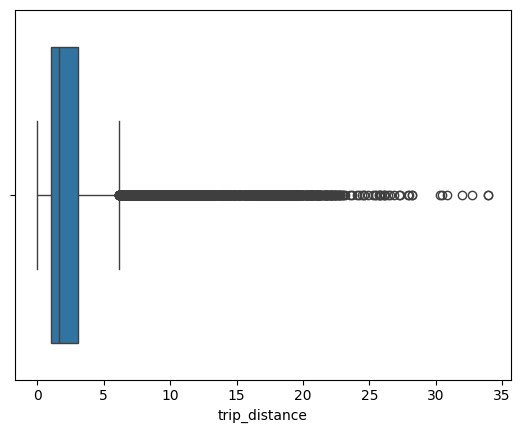

In [23]:
sns.boxplot(x=df['trip_distance'])

### **4) 팁**

In [16]:
df['tip_amount'].sort_values(ascending=False)

8478     200.00
6066      55.50
13863     51.64
12513     46.69
986       42.29
          ...  
11072      0.00
11073      0.00
11077      0.00
11081      0.00
22659      0.00
Name: tip_amount, Length: 22695, dtype: float64

### **5) 톨게이트 요금**

In [17]:
df['tolls_amount'].sort_values(ascending=False)

5273     19.10
16707    18.28
4887     18.26
18890    18.00
13361    18.00
         ...  
19        0.00
20        0.00
21        0.00
619       0.00
22684     0.00
Name: tolls_amount, Length: 22695, dtype: float64

# **4. 날짜 계산하기**

2개 이상이면 이상치로 간주
- trip_distance == 0
- fare_amount > 100
- trip_duration < 1분

In [28]:
# 0) 목표: (조건 3개 중 2개 이상 만족) 이상치 의심 행을 찾아 제거

# 1) 시간 컬럼을 datetime으로 변환 (깨진 값은 NaT로 처리)
df['tpep_pickup_datetime']  = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], errors='coerce')

# 2) 탑승 시간(초) 계산: dropoff - pickup
df['trip_duration_sec'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()

# 3) 조건 3개 만들기
c1 = df['trip_distance'] == 0          # 거리 0
c2 = df['fare_amount'] > 100           # 요금 100 초과
c3 = df['trip_duration_sec'] < 60      # 시간 1분 미만

# 4) 조건 3개 중 2개 이상 True면 이상치로 표시
bad = (c1.astype(int) + c2.astype(int) + c3.astype(int)) >= 2

# 5-A) 이상치로 걸린 행만 따로 보기
df_bad = df.loc[bad]
print(df_bad.shape)

# 5-B) 이상치 제거한 데이터 만들기
df_clean = df.loc[~bad].copy()

# 6) 제거 전후 분포/결측 비교(품질 확인)
print(df[['trip_distance','fare_amount','trip_duration_sec']].describe())
print(df_clean[['trip_distance','fare_amount','trip_duration_sec']].describe())

(128, 10)
       trip_distance   fare_amount  trip_duration_sec
count    22695.00000  22695.000000       22695.000000
mean         2.91235     13.023307        1020.721921
std          3.65152     13.240724        3720.069813
min          0.00000   -120.000000       -1019.000000
25%          0.99000      6.500000         399.000000
50%          1.61000      9.500000         670.000000
75%          3.06000     14.500000        1103.000000
max         33.96000    999.990000       86373.000000
       trip_distance   fare_amount  trip_duration_sec
count   22567.000000  22567.000000       22567.000000
mean        2.928430     12.902154        1026.438295
std         3.655236     10.823977        3729.828670
min         0.000000   -120.000000       -1019.000000
25%         1.000000      6.500000         403.000000
50%         1.630000      9.500000         674.000000
75%         3.090000     14.500000        1107.000000
max        33.960000    200.010000       86373.000000


# **5. Credit Card + Debit Card -> Card 로 통합**

In [32]:
df['payment_method'] = df['payment_method'].astype(str).str.strip()
df['payment_method'] = df['payment_method'].replace({'Credit Card': 'Card', 'Debit Card': 'Card'})

# **6. 주행시간–주행거리–요금의 상관관계 분석**

In [33]:
# 주행시간(trip_duration_sec) 만들기
df['trip_duration_sec'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()

In [ ]:
df[['trip_distance','fare_amount']].dtypes

trip_distance    float64
fare_amount      float64
dtype: object

In [35]:
df[['trip_distance','fare_amount','trip_duration_sec']].corr()

,trip_distance,fare_amount,trip_duration_sec
trip_distance,1.000000,0.934628,0.152657
fare_amount,0.934628,1.000000,0.160463
trip_duration_sec,0.152657,0.160463,1.000000


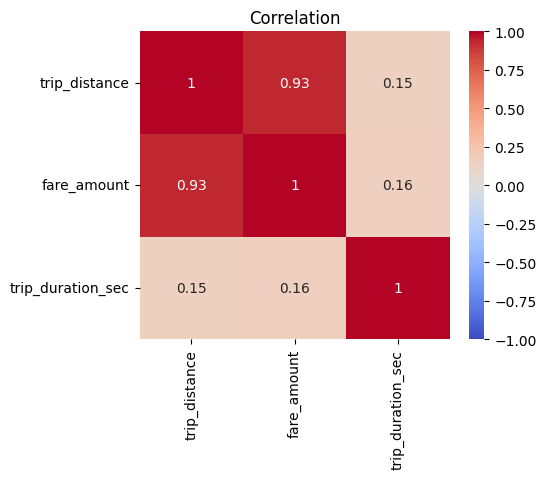

In [37]:
corr = df[['trip_distance','fare_amount','trip_duration_sec']].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation')
plt.show()

- 택시 요금은 주행 시간보다 주행 거리와 훨씬 강한 상관관계를 가지며, 도심 교통 특성상 시간–거리 간 상관은 상대적으로 낮게 나타났다.